<a href="https://colab.research.google.com/github/bodapooja375/energy-consumption-forecasting/blob/main/energy_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip

--2026-03-06 11:54:26--  https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘household_power_consumption.zip’

household_power_con     [    <=>             ]  19.68M  25.0MB/s    in 0.8s    

2026-03-06 11:54:27 (25.0 MB/s) - ‘household_power_consumption.zip’ saved [20640916]



In [6]:
!unzip household_power_consumption.zip

Archive:  household_power_consumption.zip
  inflating: household_power_consumption.txt  


In [7]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [9]:
data = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values='?'
)

data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
data['Datetime'] = pd.to_datetime(
    data['Date'] + ' ' + data['Time'],
    dayfirst=True
)

data.set_index('Datetime', inplace=True)

In [11]:
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [12]:
data = data.fillna(method='ffill')

/tmp/ipykernel_235/917065080.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


In [13]:
daily_avg = data['Global_active_power'].resample('D').mean()

In [14]:
variance = data['Global_active_power'].resample('D').var()

In [15]:
features = pd.DataFrame({
    "daily_avg": daily_avg,
    "variance": variance
}).dropna()

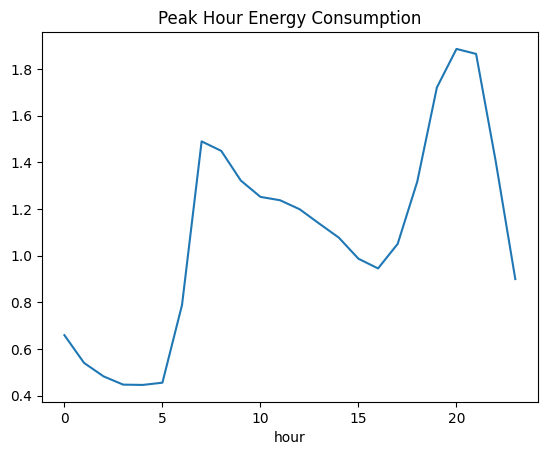

In [16]:
data['hour'] = data.index.hour

peak_hour = data.groupby('hour')['Global_active_power'].mean()

peak_hour.plot()
plt.title("Peak Hour Energy Consumption")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)

features['cluster'] = kmeans.fit_predict(features)

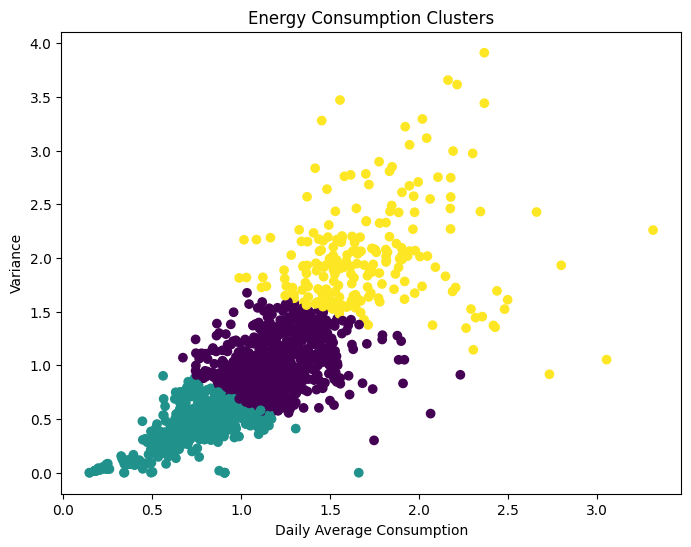

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    features['daily_avg'],
    features['variance'],
    c=features['cluster'],
    cmap='viridis'
)

plt.xlabel("Daily Average Consumption")
plt.ylabel("Variance")
plt.title("Energy Consumption Clusters")

plt.show()

In [19]:
features['target'] = features['daily_avg'].shift(-1)

features.dropna(inplace=True)

In [20]:
X = features[['daily_avg','variance','cluster']]
y = features['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [22]:
gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [23]:
def evaluate(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2

In [24]:
rf_results = evaluate(y_test, rf_pred)
gb_results = evaluate(y_test, gb_pred)

print("Random Forest Results")
print("RMSE:", rf_results[0])
print("MAE:", rf_results[1])
print("R2:", rf_results[2])

print()

print("Gradient Boosting Results")
print("RMSE:", gb_results[0])
print("MAE:", gb_results[1])
print("R2:", gb_results[2])

Random Forest Results
RMSE: 0.3433573142254829
MAE: 0.2624965830912147
R2: 0.39289322216344413

Gradient Boosting Results
RMSE: 0.3327447994898536
MAE: 0.24471920057325963
R2: 0.42984225500221196


In [25]:
print("Gradient Boosting performs better due to lower RMSE and higher R2 score.")

Gradient Boosting performs better due to lower RMSE and higher R2 score.


In [26]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "RMSE": [rf_results[0], gb_results[0]],
    "MAE": [rf_results[1], gb_results[1]],
    "R2 Score": [rf_results[2], gb_results[2]]
})

comparison

,Model,RMSE,MAE,R2 Score
0,Random Forest,0.343357,0.262497,0.392893
1,Gradient Boosting,0.332745,0.244719,0.429842


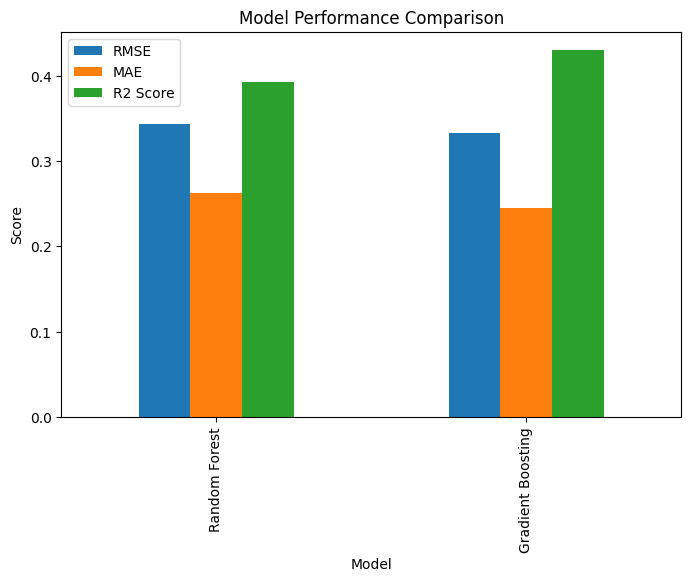

In [27]:
comparison.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

In [28]:
# Create comparison table

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "RMSE": [rf_results[0], gb_results[0]],
    "MAE": [rf_results[1], gb_results[1]],
    "R2 Score": [rf_results[2], gb_results[2]]
})

print("MODEL PERFORMANCE COMPARISON")
print("--------------------------------")
display(comparison)

print("\nINTERPRETATION:")

if gb_results[0] < rf_results[0]:
    print("Gradient Boosting has lower RMSE, meaning smaller prediction errors.")

if gb_results[1] < rf_results[1]:
    print("Gradient Boosting has lower MAE, meaning predictions are closer to actual values.")

if gb_results[2] > rf_results[2]:
    print("Gradient Boosting has higher R2 score, meaning it explains more variance in energy consumption.")

print("\nCONCLUSION:")
print("Cluster-based modeling helps identify households with similar energy consumption patterns.")
print("Using these clusters as features improves forecasting performance.")
print("Overall, Gradient Boosting performs better than Random Forest for this dataset.")

MODEL PERFORMANCE COMPARISON
--------------------------------


,Model,RMSE,MAE,R2 Score
0,Random Forest,0.343357,0.262497,0.392893
1,Gradient Boosting,0.332745,0.244719,0.429842



INTERPRETATION:
Gradient Boosting has lower RMSE, meaning smaller prediction errors.
Gradient Boosting has lower MAE, meaning predictions are closer to actual values.
Gradient Boosting has higher R2 score, meaning it explains more variance in energy consumption.

CONCLUSION:
Cluster-based modeling helps identify households with similar energy consumption patterns.
Using these clusters as features improves forecasting performance.
Overall, Gradient Boosting performs better than Random Forest for this dataset.
